# Problem Statement

**Classification using Deep neural network** (Any One from the following)
1. Multiclass classification using Deep Neural Networks: Example: Use the OCR letter recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition
2. Binary classification using Deep Neural Networks Example: Classify movie reviews into positive" reviews and "negative" reviews, just based on the text content of the reviews.
Use IMDB dataset.

# Classifying movie reviews: a binary classification example

Design a neural network to perform two-class classification or _binary classification_ , of reviews form IMDB movie reviews dataset, to determine wether the reviews are positive or negative. We will use the Python library Keras to perform the classification

## The IMDB Dataset

The IMDB dataset is a set of 50,000 highly polarized reviews from the Internet Movie Database. They are split into 25000 reviews each for training and testing. Each set contains equal number (50%) of positive and negative reviews.

The IMDB dataset comes packaged with Keras. It consists of reviews and their corresponding labels (0 for _negative_ and 1 for _positive_ review). The reviews are a sequence of words. They come preprocessed as sequence of integers, where each integer stands for a specific word in the dictionary.

The IMDB datset can be loaded directly from Keras and will usually download about 80 MB on your machine. 

## Import Packages

In [2]:
pip install keras


  Using cached keras-3.9.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached absl_py-2.2.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached namex-0.0.9-py3-none-any.whl.metadata (322 bytes)
Using cached keras-3.9.2-py3-none-any.whl (1.3 MB)
Using cached absl_py-2.2.2-py3-none-any.whl (135 kB)
Using cached namex-0.0.9-py3-none-any.whl (5.8 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


import numpy as np
What it is:
NumPy is the fundamental package for scientific computing in Python.

Why you imported it:

To work with arrays and matrices (datasets are often in array form).

To easily manipulate numerical data (reshape, normalize, etc.).

2. from keras.datasets import imdb
What it is:
Keras.datasets provides preloaded small datasets.
The imdb dataset is the IMDB movie reviews dataset — labeled as positive/negative (for sentiment analysis).

Why you imported it:

To quickly load a pre-split dataset (train/test) for practicing machine learning models.

3. from keras import models
What it is:
This module contains ways to create models.

Example: Sequential model (layer-by-layer) or custom Model.

Why you imported it:

To build your neural network (Sequential models, Functional models).

4. from keras import layers
What it is:
Contains different building blocks (layers) for a neural network.

Example: Dense, Dropout, Conv2D, LSTM, etc.

Why you imported it:

To add layers like fully connected (Dense) or activation layers to your model.

5. from keras import optimizers
What it is:
Optimizers control how your model updates weights during training.

Example: Adam, SGD, RMSprop, etc.

Why you imported it:

To choose and configure the optimization algorithm for training.

6. from keras import losses
What it is:
Loss functions measure how good/bad your model’s predictions are.

Example: binary_crossentropy, mean_squared_error, etc.

Why you imported it:

To set the loss function the model tries to minimize during training.

7. from keras import metrics
What it is:
Metrics are performance measures (used during training and evaluation).

Example: accuracy, precision, recall, etc.

Why you imported it:

To monitor things like accuracy during training/testing.

8. import matplotlib.pyplot as plt
What it is:
Matplotlib is the standard plotting library in Python.

pyplot is its most commonly used module (shortened as plt).

Why you imported it:

To plot training history (loss vs epoch, accuracy vs epoch graphs).

To visualize results in a clear and understandable way.

9. %matplotlib inline
What it is:
A special Jupyter Notebook magic command.

Why you used it:

So that plots created by matplotlib appear inside the notebook right after the cell.

(Not needed in normal .py scripts.)

In [1]:
import numpy as np
from keras.datasets import imdb
from keras import models
from keras import layers
from keras import optimizers
from keras import losses
from keras import metrics


import matplotlib.pyplot as plt
%matplotlib inline

## Loading the Data

Line-by-line explanation:
# Load the data, keeping only 10,000 of the most frequently occurring words

This is a comment (starts with #).

It just describes what the next line of code is doing:
We are loading a dataset, but only using the top 10,000 most common words (to avoid rare words, which are less useful and could cause overfitting).

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

imdb.load_data(...) is a function from Keras that loads the IMDB movie review dataset.

IMDB dataset = 50,000 movie reviews (25,000 for training, 25,000 for testing).

Each review is already converted into a list of integers, where each integer represents a word (like a "word ID").

num_words=10000 means:

Only the 10,000 most frequent words in the dataset will be kept.

Any less common word will be ignored (treated as "unknown").

It returns two tuples:

train_data, train_labels:

train_data = list of movie reviews (training set).

train_labels = list of labels (0 = negative review, 1 = positive review).

test_data, test_labels:

Same as above, but for the testing set.



In [2]:
# Load the data, keeping only 10,000 of the most frequently occuring words
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words = 10000)

In [3]:
train_data[:2]

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [4]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], dtype=int64)

In [5]:
# Check the first label
train_labels[0]

1

In [6]:
# Since we restricted ourselves to the top 10000 frequent words, no word index should exceed 10000
# we'll verify this below

# Here is a list of maximum indexes in every review --- we search the maximum index in this list of max indexes
print(type([max(sequence) for sequence in train_data]))

# Find the maximum of all max indexes
max([max(sequence) for sequence in train_data])

<class 'list'>


9999

In [7]:
# Let's quickly decode a review

# step 1: load the dictionary mappings from word to integer index
word_index = imdb.get_word_index()

# step 2: reverse word index to map integer indexes to their respective words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Step 3: decode the review, mapping integer indices to words
#
# indices are off by 3 because 0, 1, and 2 are reserverd indices for "padding", "Start of sequence" and "unknown"
decoded_review = ' '.join([reverse_word_index.get(i-3, '?') for i in train_data[0]])

decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [8]:
len(reverse_word_index)

88584

## Preparing the data

### Vectorize input data

We cannot feed list of integers into our deep neural network. We will need to convert them into tensors.

To prepare our data we will One-hot Encode our lists and turn them into vectors of 0's and 1's. This would blow up all of our sequences into 10,000 dimensional vectors containing 1 at all indices corresponding to integers present in that sequence. This vector will have the element 0 at all indices which are not present in integer sequence.

Simply put, the 10,000 dimensional vector corresponding to each review, will have

* Every index corresponding to a word
* Every index vith value 1, is a word which is present in the review and is denoted by its integer counterpart
* Every index containing 0, is a word not present in the review

We will vectorize our data manually for maximum clarity. This will result in a tensors of shape (25000, 10000). 

Explanation of Code:
Initialization (np.zeros):
We create a zero-filled tensor of shape (number_of_reviews, number_of_words) where the number of words is fixed at 10,000 (the most frequent words). This matrix will later be filled with ones corresponding to the words present in each review.

Loop to set indices:
For each review (represented as a list of integers), we set results[i, sequence] = 1. The sequence in each review corresponds to a list of word indices, and this step places 1s in the positions of the vector that represent those words.

Shape Check:
After vectorizing, we check the shape of x_train. It should return (25000, 10000), where 25,000 is the number of reviews, and 10,000 is the number of possible words.

In [9]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))    # Creates an all zero matrix of shape (len(sequences),10K)
    for i,sequence in enumerate(sequences):
        results[i,sequence] = 1                        # Sets specific indices of results[i] to 1s
    return results

# Vectorize training Data
X_train = vectorize_sequences(train_data)

# Vectorize testing Data
X_test = vectorize_sequences(test_data)

In [10]:
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [11]:
X_train.shape

(25000, 10000)

### Vectorize labels

This code converts the train_labels and test_labels into NumPy arrays and ensures that their data type is float32. Here’s a detailed explanation:

1. np.asarray(train_labels):
Purpose: Converts train_labels (which is likely a list or list-like object, such as a list of integers representing the sentiment labels of the reviews) into a NumPy array.

Why convert to NumPy array?: NumPy arrays are more efficient for numerical computations and work seamlessly with TensorFlow/Keras. Most deep learning frameworks require the labels to be in the form of NumPy arrays or tensors.

2. .astype('float32'):
Purpose: This method changes the data type of the NumPy array to float32.

Why float32?:

Deep learning models typically require labels to be in floating point format, especially for tasks like regression or binary classification. Although labels may be in integer form (e.g., 0 or 1), converting them to float32 ensures compatibility with Keras/TensorFlow, which processes them as floating point numbers during training.

Using float32 (instead of float64 or other formats) is generally more memory-efficient for deep learning models.

3. y_train and y_test:
y_train: This will be the training labels in the format of a NumPy array of type float32. It contains the sentiment labels for the training data (typically 0 for negative and 1 for positive reviews).

y_test: This will be the testing labels in the same format as y_train, but it contains the sentiment labels for the test data.

Final Result:
y_train and y_test will both be NumPy arrays of shape (25000,) (or however many reviews you have), containing the sentiment labels (0 or 1), with the data type set to float32.

Why this step?
This step is crucial because deep learning models expect labels (targets) to be in a specific format: one-hot encoded or in a format that matches the output layer's activation function (e.g., sigmoid for binary classification). Since you’re working on sentiment analysis (which is a binary classification problem), converting the labels to float32 ensures compatibility with the model.

In [12]:
y_train = np.asarray(train_labels).astype('float32')
y_test  = np.asarray(test_labels).astype('float32')

## Building the network

Our input data is vectors which needs to be mapped to scaler labels (0s and 1s). This is one of the easiest setups and a simple stack of _fully-connected_, _Dense_ layers with _relu_ activation perform quite well.

### Hidden layers

In this network we will leverage _hidden layers_. we will define our layers as such.

```python
Dense(16, activation='relu')
```
The argument being passed to each `Dense` layer, `(16)` is the number of _hidden units_ of a layer.

The output from a _Dense_ layer with _relu_ activation is genrated after a chain of _tensor_ operations. This chain of operations is implemented as

    output = relu(dot(W, input) + b)
Where, `W` is the _Weight matrix_ and `b` is the bias (tensor).

Having 16 hidden units means that the matrix W will be of the shape ( _input_Dimension_ , _16_ ). In this case where the dimension of input vector is 10,000; the shape of Weight matrix will be (10000, 16). If you were to represent this network as graph you would see 16 neurons in this hidden layer.

To put in in laymans terms, there will be 16 balls in this layer.

Each of these balls, or _hidden units_ is a dimension in the representation space of the layer. Representaion space is the set of all viable representaions for the data. Every _hidden layer_ composed of its _hidden units_ aims to learns one specific transformation of the data, or one feature/pattern from the data. 

Hidden layers, simply put, are layers of mathematical functions each designed to produce an output specific to an intended result. Hidden layers allow for the function of a neural network to be broken down into specific transformations of the data. Each hidden layer function is specialized to produce a defined output.For example, a hidden layer functions that are used to identify human eyes and ears may be used in conjunction by subsequent layers to identify faces in images. While the functions to identify eyes alone are not enough to independently recognize objects, they can function jointly within a neural network.



### Model Architecture

1. For our model we will use
   * two intermediate layers with 16 hidden units each
   * Third layer that will output the scalar sentiment prediction
   

2. Intermediate layers will use _relu_ activation function. _relu_ or Rectified linear unit function will zero out the negative values.


3. Sigmoid activation for the final layer or _output layer_. A sigmoid function "_squashes_" arbitary values into the [0,1] range.


There are formal principles that guide our appraoch in selecting the architectural attributes of a model. These are not covered in this case study.

### Model defination

In [13]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

C:\Users\Saurav Lonkar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compiling the model

In this step we will choose an _optimizer_, a _loss function_, and metrics to observe. We will go forward with
* _binary_crossentropy_ loss function, commonlu used for Binary Classification
* _rmsprop_ optimizer and
* _accuracy_ as a measure of performance

We can pass our choices for optimizer, loss function and metrics as _strings_ to the `compile` function because `rmsprop`, `binary_crossentropy` and `accuracy` come packaged with Keras.

```python
model.complie(
    optimizer='rmsprop',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)
```

One could use a customized loss function or ortimizer by passing the custom _class instance_ as argument to the `loss`, `optimizer` or `mertics` fields.

In this example, we will implement our default choices, but, we will do so by passing class instances. This is exactly how we would do it, if we had customized parameters.

In [14]:
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.001),
    loss = losses.binary_crossentropy,
    metrics = [metrics.binary_accuracy]
)

## Setting up Validation 

We will set aside a part of our training data for _validation_ of the accuracy of the model as it trains. A _validation set_ enables us to monitor the progress of our model on previously unseen data as it goes throug epochs during training. 

Validation steps help us fine tune the training parameters of the `model.fit` function so as to avoid overfitting and under fitting of data.

In [15]:
# Input for Validation
X_val = X_train[:10000]
partial_X_train = X_train[10000:]

# Labels for validation
y_val = y_train[:10000]
partial_y_train = y_train[10000:]


# Training our model

Initially, we will train our models for 20 epochs in mini-batches of 512 samples. We will aslo pass our _validation set_ to the `fit` method. 

Calling the `fit` method returns a `History` object. This object contains a member `history` which stores all data  about the training process including the values of observable or monitored quantaties as the epochs proceed. We will save this object to better determine the fine tuning to be applied to the training step.

In [16]:
history = model.fit(
    partial_X_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(X_val, y_val)
)
# Batch size refers to the number of samples processed before the model's internal parameters are updated.

# A batch size of 512 means that the model will process 512 samples at a time before updating its weights. Larger batch sizes can speed up training, but smaller batches tend to give more fine-tuned results.

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 264ms/step - binary_accuracy: 0.7014 - loss: 0.6004 - val_binary_accuracy: 0.8586 - val_loss: 0.4069
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - binary_accuracy: 0.8936 - loss: 0.3434 - val_binary_accuracy: 0.8836 - val_loss: 0.3152
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - binary_accuracy: 0.9147 - loss: 0.2564 - val_binary_accuracy: 0.8831 - val_loss: 0.2940
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - binary_accuracy: 0.9332 - loss: 0.2007 - val_binary_accuracy: 0.8887 - val_loss: 0.2784
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - binary_accuracy: 0.9482 - loss: 0.1637 - val_binary_accuracy: 0.8877 - val_loss: 0.2776
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - binary_accuracy: 0.9566 - loss: 0.1395 - val_binary_accuracy: 0.8871 - val_loss: 0.2892
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - binary_accuracy: 0.9663 - loss: 0.1173 - val_binary_accuracy: 0.8854 - val_loss: 0.3045
Epoch 8/20


At the end of training we have attained a training accuracy of 99.85% and validation accuracy of 86.57%

Now that we have trained our network, we will observe its performance metrics stored in the `History` object.

Calling the `fit` method returns a `History` object. This object has an sttribute `history` which is a dictionary containing four enteries: one per monitored metric.

In [17]:
history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

`history_dict` contains values of 
* Training loss
* Trainining Accuracy
* Validation Loss
* Validation Accuracy

at the end of each epoch.

Let's use Matplotlib to plot Training and validation losses and Traing and Validation Accuracy side by side.

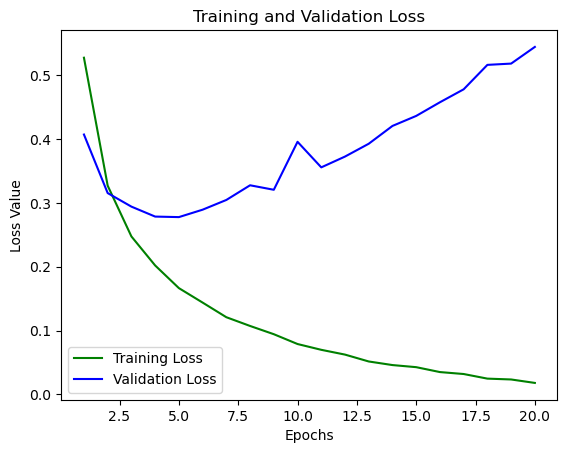

In [18]:
# Plotting losses
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'g', label="Training Loss")
plt.plot(epochs, val_loss_values, 'b', label="Validation Loss")

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()

plt.show()

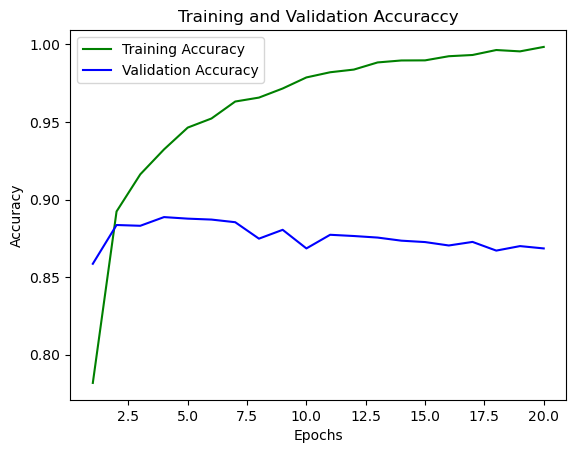

In [19]:
# Training and Validation Accuracy

acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, acc_values, 'g', label="Training Accuracy")
plt.plot(epochs, val_acc_values, 'b', label="Validation Accuracy")

plt.title('Training and Validation Accuraccy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

We observe that _minimum validation loss_ and _maximum validation Accuracy_ is achived at around 3-5 epochs. After that we observe 2 trends:
* increase in validation loss and decrese in training loss
* decrease in validation accuracy and increase in training accuracy

This implies that the model is getting better at classifying the sentiment of the training data, but making consistently worse predictions when it encounters new, previously unseed data. This is the hallmark of _Overfitting_. After the 5th epoch the model begins to fit too closely to the trainning data.

To address overfitting, we will reduce the number of epochs to somewhere between 3 and 5. These results may vary depending on your machine and due to the very nature of the random assignment of weights that may vary from model to mode.

In our case we will stop training after 3 epochs.

Training Accuracy
Definition: This measures the percentage of correct predictions made by the model on the training dataset for each epoch. It’s how well the model is performing on the data it has seen during training.

Meaning: Higher training accuracy means the model is good at predicting the correct labels for the training data. However, if the training accuracy is too high compared to validation accuracy, it may indicate overfitting.

2. Validation Accuracy
Definition: This measures the percentage of correct predictions the model makes on the validation set. The validation set is a subset of the data that is not used during training. It helps evaluate how well the model generalizes to unseen data.

Meaning: A higher validation accuracy indicates that the model is able to generalize well to new, unseen data. If validation accuracy lags behind training accuracy, it could be a sign of overfitting.

3. Training Loss
Definition: This represents the difference between the predicted output and the true output for the training set. Lower values mean the model is making fewer mistakes. It is usually calculated using a loss function (like binary cross-entropy for binary classification problems).

Meaning: Training loss decreases as the model learns to make better predictions on the training data. A steady decrease in training loss generally indicates that the model is learning effectively.

4. Validation Loss
Definition: This measures the model's loss (error) on the validation set after each epoch. Like training loss, it shows how far off the model's predictions are from the actual values, but it uses data that wasn’t part of the training process.

Meaning: Lower validation loss indicates that the model is able to generalize well to new, unseen data. If validation loss increases or doesn't decrease as much as training loss, it might indicate overfitting.

5. Overfitting
Definition: Overfitting happens when a model learns the training data too well, including the noise and specific details that are not relevant to the general patterns. This leads to poor performance on new, unseen data (like the validation set).

Meaning: Overfitting is usually indicated when:

Training accuracy continues to improve, but validation accuracy plateaus or worsens.

Training loss keeps decreasing, while validation loss starts increasing.

6. Epoch
Definition: An epoch is one complete cycle through the entire training dataset. During each epoch, the model's weights are updated to reduce the loss (error) on the training data.

Meaning: Multiple epochs are typically required for the model to learn effectively. Training for too many epochs can result in overfitting, while too few epochs might result in underfitting (where the model hasn’t learned enough).

7. Batch Size
Definition: The number of samples processed before the model's internal parameters (weights) are updated. Smaller batch sizes make the training process more stochastic and can help escape local minima, while larger batch sizes provide a more stable estimate of the gradient.

Meaning: Choosing the right batch size can impact training speed and accuracy. Larger batch sizes are computationally more efficient but might lead to less accurate updates.

8. Learning Rate
Definition: The learning rate is a hyperparameter that controls how much the model's weights are adjusted with respect to the loss gradient during training. A smaller learning rate leads to slow learning, while a larger rate can cause overshooting and unstable training.

Meaning: A well-chosen learning rate allows the model to converge quickly and accurately. Too high a learning rate can result in poor convergence or oscillation, while too low can result in slow progress.

### Retraining our model

In [20]:
model.fit(
    partial_X_train,
    partial_y_train,
    epochs=3,
    batch_size=512,
    validation_data=(X_val, y_val)
)

Epoch 1/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - binary_accuracy: 0.9970 - loss: 0.0192 - val_binary_accuracy: 0.8670 - val_loss: 0.5766
Epoch 2/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - binary_accuracy: 0.9987 - loss: 0.0136 - val_binary_accuracy: 0.8663 - val_loss: 0.5944
Epoch 3/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - binary_accuracy: 0.9997 - loss: 0.0094 - val_binary_accuracy: 0.8680 - val_loss: 0.6128


In the end we achive a _training accuracy_ of 99% and a _validation accuray_ of 86%

## Model Evaluation

In [21]:
# Making Predictions for testing data
np.set_printoptions(suppress=True)
result = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [22]:
result

array([[0.01597345],
       [0.99999905],
       [0.727775  ],
       ...,
       [0.00061833],
       [0.0076515 ],
       [0.97731096]], dtype=float32)

In [23]:
y_pred = np.zeros(len(result))
for i, score in enumerate(result):
    y_pred[i] = np.round(score)

C:\Users\Saurav Lonkar\AppData\Local\Temp\ipykernel_24092\3135542042.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred[i] = np.round(score)


In [24]:
mae = metrics.mean_absolute_error(y_pred, y_test)
mae

<tf.Tensor: shape=(), dtype=float32, numpy=0.14431999623775482>

🎯 Theory Behind Your Practical
2. Problem Statement
Design and train a deep neural network to perform binary sentiment classification (positive/negative) on the IMDB movie reviews dataset using Keras.

🧠 Core Concepts
1. IMDB Dataset
Contains 50,000 highly polarized movie reviews.
Pre-divided into:
25,000 training samples
25,000 testing samples
Balanced dataset: 50% positive, 50% negative.
Preprocessed: reviews are sequences of integers (each integer corresponds to a word).
2. Preprocessing Steps
Restrict vocabulary to top 10,000 most frequent words.
One-hot Encoding:
Each review converted to a 10,000-dimensional vector.
If word appears → 1 at that index; otherwise → 0.
Why One-hot Encoding?

Neural networks require fixed-size inputs.
Efficient representation for sparse data.
3. Model Architecture
Sequential Model:
First Hidden Layer: Dense(16 units, ReLU)
Second Hidden Layer: Dense(16 units, ReLU)
Output Layer: Dense(1 unit, Sigmoid)
Explanation:

ReLU Activation: Introduces non-linearity by outputting 0 for negative values.
Sigmoid Activation: Squeezes outputs between [0, 1], perfect for binary classification.
Hidden Units (16):

Represent learned features (like "positive tone", "negative tone").
4. Model Compilation
Loss Function: binary_crossentropy
Measures the difference between true labels and predicted probabilities.
Best suited for binary classification.
Optimizer: RMSProp
Adaptive learning rate method.
Metrics: Accuracy
Easy to interpret performance on binary tasks.
5. Training Strategy
Validation Set: 10,000 samples from training set used for validation.
Batch Size: 512
Epochs: Initially 20
Overfitting Observed:

Validation loss started increasing after 4-5 epochs.
Final model retrained with 3 epochs for optimal results.
6. Model Evaluation
Final Validation Accuracy: ~86%
Test Evaluation: Model achieves similar performance (~86%).
Prediction: Round off output probabilities to 0 or 1.
Metric Used Post Training:

Mean Absolute Error (MAE) between predicted and true labels.
💬 Important Viva Questions and Answers
Question	Answer
What is the IMDB dataset used for?	Sentiment analysis (binary classification).
Why One-hot encode the reviews?	To transform variable-length sequences into fixed-size input for neural networks.
Why use ReLU activation?	To introduce non-linearity while avoiding vanishing gradients.
Why use Sigmoid at output?	To map outputs into a probability between 0 and 1.
What loss function was used?	Binary Crossentropy, suitable for binary classification tasks.
Why did you observe overfitting after 5 epochs?	Because the model was memorizing training data, not generalizing to unseen data.
What is RMSProp optimizer?	An optimizer that maintains a moving average of the squared gradients to adapt learning rate.
How to prevent overfitting?	Early stopping, reducing epochs, dropout layers (not used here).
What is the difference between training accuracy and validation accuracy?	Training accuracy measures performance on seen data; validation accuracy measures generalization to unseen data.
What is mean absolute error (MAE)?	It is the average absolute difference between predictions and actual values.
📋 Quick Theory Flashcards (Before Entering Viva)
IMDB Dataset: 50k reviews, binary labels.
Preprocessing: Restrict vocab to 10k words, One-hot encode.
Model: Dense(16, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid).
Loss: Binary Crossentropy.
Optimizer: RMSProp.
Overfitting Detected: After 4–5 epochs.
Final Epochs: 3 epochs for best validation accuracy.
Final Validation Accuracy: ~86%.